# Kodowanie dyskretnych problemów optymalizacyjnych za pomocą QUBO / Isinga.

## Przykład - zapisanie problemu MAX-CUT jako QUBO (Zadanie Domowe)

Problem Max Cut jest jednym z najbardziej znanych problemów optymalizacji kombinatorycznej. Dla danego grafu nieskierowanego $G(V,E)$ ze zbiorem wierzchołków  $V$ oraz zbiorem krawędzi  $E$, problem Max Cut polega na podziale zbioru  $V$ na dwa podzbiory, $S$, $T$, $S \cup T = V$, tak aby liczba krawędzi łączących te podzbiory (tzw. przeciętych przez cięcie) była jak największa.


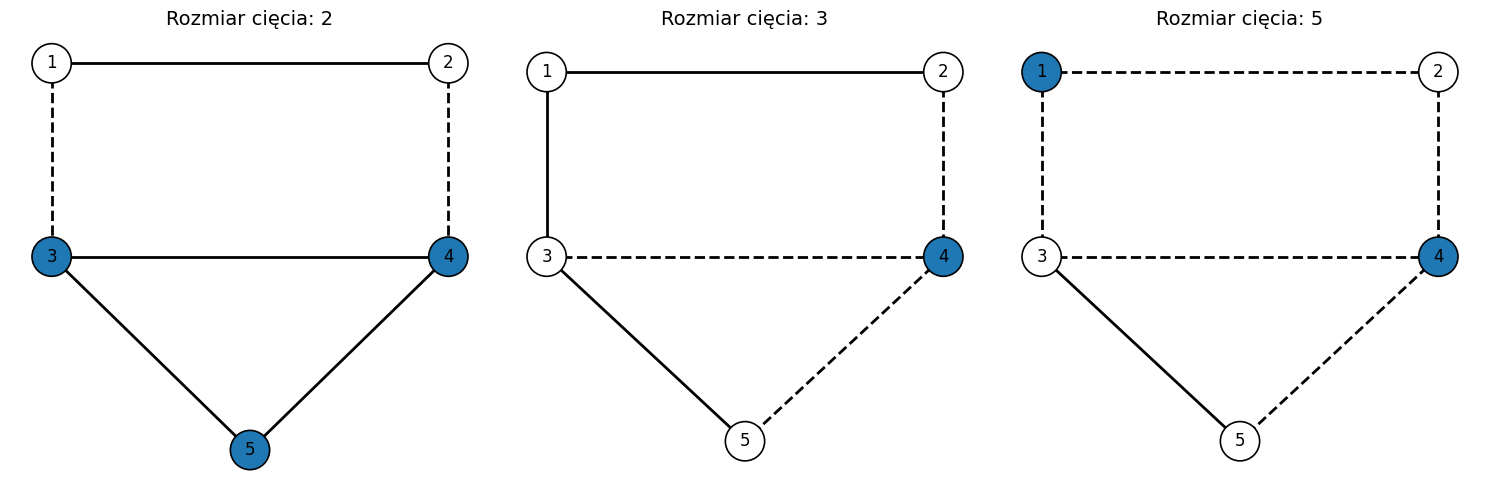

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Utwórz graf
G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5])
G.add_edges_from([
    (1, 2),  # krawędź górna
    (1, 3),  # krawędź pionowa lewa
    (2, 4),  # krawędź pionowa prawa
    (3, 4),  # krawędź środkowa pozioma
    (3, 5),  # przekątna lewa
    (4, 5),  # przekątna prawa
])

# Stałe pozycje węzłów dla powtarzalnego układu
pos = {
    1: (0.0,  1.0),
    2: (1.0,  1.0),
    3: (0.0,  0.0),
    4: (1.0,  0.0),
    5: (0.5, -1.0),
}

# Definicja trzech rozcięć (zbiory S) wraz z tytułami
cuts = [
    ({3, 4, 5}, "Rozmiar cięcia: 2"),
    ({4},       "Rozmiar cięcia: 3"),
    ({1, 4},    "Rozmiar cięcia: 5"),
]

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
for ax, (S, title) in zip(axes, cuts):
    T = set(G.nodes()) - S
    # Podział krawędzi na: wewnątrz S, wewnątrz T oraz krawędzie cięcia
    edges_inside_S = [(u, v) for u, v in G.edges() if u in S and v in S]
    edges_inside_T = [(u, v) for u, v in G.edges() if u in T and v in T]
    edges_cut      = [(u, v) for u, v in G.edges() if (u in S) ^ (v in S)]

    # Rysuj węzły: niebieskie jeśli w S, białe w przeciwnym wypadku
    node_colors = ["tab:blue" if n in S else "white" for n in G.nodes()]
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=G.nodes(),
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.2,
        node_size=800,
        ax=ax
    )
    nx.draw_networkx_labels(
        G, pos,
        labels={n: str(n) for n in G.nodes()},
        font_color="black",
        font_size=12,
        ax=ax
    )

    # Rysuj krawędzie wewnątrz T 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_inside_T,
        style="solid",
        edge_color="black",
        width=2.0,
        ax=ax
    )
    # Rysuj krawędzie wewnątrz S 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_inside_S,
        style="solid",
        edge_color="black",
        width=2.0,
        ax=ax
    )
    # Rysuj krawędzie cięcia 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_cut,
        style="dashed",
        edge_color="black",
        width=2.0,
        ax=ax
    )

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

plt.tight_layout()
plt.show()




### 1. Zmienne binarne

Dla każdego wierzchołka $i \in V$ wprowadzamy zmienną binarną:

$$
x_i \in \{0,1\},
$$

gdzie:

- $x_i = 0$ oznacza, że wierzchołek $i$ należy do pierwszego podzbioru,
- $x_i = 1$ oznacza, że wierzchołek $i$ należy do drugiego podzbioru.

Krawędź $(i,j)$ należy do cięcia wtedy i tylko wtedy, gdy końce tej krawędzi znajdują się po przeciwnych stronach, czyli gdy:

$$
x_i \neq x_j.
$$


### 2. Funkcja celu

Dla zmiennych binarnych warunek $x_i \neq x_j$ można zapisać za pomocą wyrażenia:

$$
x_i + x_j - 2x_i x_j.
$$

Sprawdźmy:

- jeśli $x_i = x_j = 0$, to wartość wynosi $0$,
- jeśli $x_i = 0, x_j = 1$, to wartość wynosi $1$,
- jeśli $x_i = 1, x_j = 0$, to wartość wynosi $1$,
- jeśli $x_i = x_j = 1$, to wartość wynosi $0$.




### 3. Przejście do formulacji QUBO

Model QUBO wymaga zapisania zadania w postaci minimalizacji funkcji kwadratowej zmiennych binarnych:

$$
\min \; x^T Q x,
\qquad x \in \{0,1\}^n.
$$

Ponieważ problem Max-Cut jest zadaniem maksymalizacyjnym, przechodzimy do wersji minimalizacyjnej przez zmianę znaku funkcji celu:


$$
\min \sum_{(i,j)\in E} \left( -x_i - x_j + 2x_i x_j \right).
$$

Jest to już funkcja kwadratowa zmiennych binarnych, a więc poprawna postać QUBO.



#### Interpretacja współczynników

W powyższej formulacji:

- składniki liniowe $-x_i$ i $-x_j$ premiują przypisanie wierzchołków do jednej z części,
- składnik kwadratowy $x_i x_j$ koryguje tę premię tak, aby największą wartość uzyskiwały rozwiązania, w których końce krawędzi znajdują się w różnych częściach.

Najważniejsze jest to, że nie są potrzebne żadne dodatkowe ograniczenia ani zmienne pomocnicze. Problem Max-Cut w naturalny sposób prowadzi do funkcji kwadratowej nad zmiennymi binarnymi.




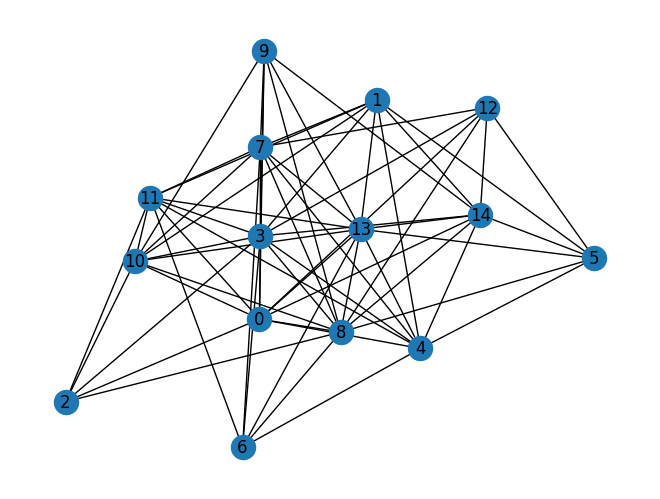

In [3]:
# Przykład grafu losowego na 15 wierzchołkach
import numpy as np
import networkx as nx

graph = nx.erdos_renyi_graph(n=15, p=0.6, seed=42)
nx.draw(graph, with_labels=True)

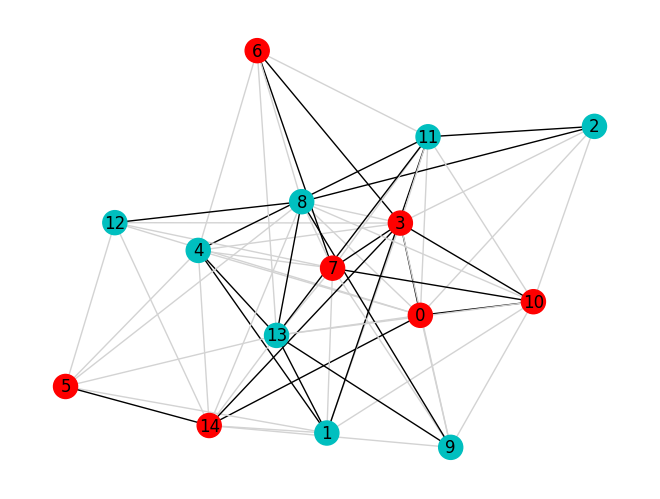

In [5]:
# Rozwiązanie problemu
from collections import defaultdict
from math import inf
from itertools import product
from dimod import BinaryQuadraticModel

Q = defaultdict(int)
for i, j in graph.edges:
    Q[(i,i)]+= -1
    Q[(j,j)]+= -1
    Q[(i,j)]+= 2

qubo = BinaryQuadraticModel(Q, "BINARY")
n = qubo.num_variables

best_energy = inf
best_state = []
for state in product([0, 1], repeat=n):
    x = np.array(state)
    energy = qubo.energy(x)
    if energy < best_energy:
        best_energy = energy
        best_state = state


# Interpretacja wyników
S0 = [node for node in graph.nodes if not best_state[node]]
S1 = [node for node in graph.nodes if best_state[node]]


uncut_edges = [(u, v) for u, v in graph.edges if best_state[u]==best_state[v]]

# narysowanie najlepszego znalezionego wyniku
nx.draw(graph, node_color=["r" if i in S0 else "c" for i in list(graph.nodes)], with_labels=True, 
       edge_color=["black" if e in uncut_edges else "lightgray" for e in list(graph.edges)])

## Problem komiwojażera (TSP) i jego sprowadzenie do postaci QUBO

### 1. Definicja problemu

Dany jest graf $G=(V,E)$, w którym każdej krawędzi $(u,v)$ przypisana jest waga $W_{uv}$. Problem komiwojażera polega na znalezieniu takiego **cyklu Hamiltona**, który przechodzi przez każde miasto dokładnie raz i ma **minimalną sumę wag** użytych krawędzi.




### 2. Kodowanie binarne

Niech

$$
N = |V|.
$$

Wprowadzamy zmienne binarne

$$
x_{v,j} \in \{0,1\},
$$

gdzie

$$
x_{v,j} = 1
\quad \Longleftrightarrow \quad
\text{miasto } v \text{ znajduje się na pozycji } j \text{ w trasie.}
$$

Interpretacja jest więc następująca:

- indeks $v$ oznacza miasto,
- indeks $j$ oznacza pozycję miasta w cyklu.

W podstawowej wersji potrzeba $N^2$ zmiennych binarnych. Ponieważ w cyklu można bez straty ogólności ustalić jedno miasto jako pierwsze, liczbę zmiennych można zredukować do $(N-1)^2$.


### 3. Ograniczenia poprawnej trasy

Aby zakodowana konfiguracja odpowiadała poprawnej trasie, muszą być spełnione trzy warunki.

#### I Każde miasto występuje dokładnie raz

$$
\sum_{j=1}^{N} x_{v,j} = 1
\qquad \forall v \in V.
$$

#### II Na każdej pozycji znajduje się dokładnie jedno miasto

$$
\sum_{v \in V} x_{v,j} = 1
\qquad \forall j=1,\dots,N.
$$

#### III Kolejne miasta w trasie muszą być połączone krawędzią

Jeżeli miasto $u$ występuje na pozycji $j$, a miasto $v$ na pozycji $j+1$, to przejście $(u,v)$ musi należeć do zbioru krawędzi $E$.

Dla cyklu indeks $j+1$ rozumiemy modulo $N$, czyli po pozycji $N$ wracamy do pozycji $1$.

$$
\sum_{(u,v) \notin E} \sum_{j=1}^N x_{u,j} x_{v, j+1} = 0
$$

### 4. Hamiltonian dla cyklu Hamiltona

Hamiltonian dla problemu cyklu Hamiltona:

$$
H_A =
A\sum_{v=1}^{N}\left(1-\sum_{j=1}^{N}x_{v,j}\right)^2
+
A\sum_{j=1}^{N}\left(1-\sum_{v=1}^{N}x_{v,j}\right)^2
+
A\sum_{(u,v)\notin E}\sum_{j=1}^{N} x_{u,j}x_{v,j+1}.
$$

Znaczenie poszczególnych składników:

1. pierwszy składnik wymusza, aby każde miasto pojawiło się dokładnie raz,
2. drugi składnik wymusza, aby każda pozycja była obsadzona dokładnie jednym miastem,
3. trzeci składnik karze przejścia między miastami, dla których nie istnieje krawędź w grafie.

Stała $A>0$ jest parametrem kary.

### 5. Dodanie kosztu podróży

Dodajemy do $H_A$ składnik kosztowy:

$$
H_B =
B\sum_{(u,v)\in E} W_{uv}\sum_{j=1}^{N} x_{u,j}x_{v,j+1}.
$$

Całkowity Hamiltonian ma postać

$$
H = H_A + H_B.
$$

Składnik $H_B$ nie wymusza poprawności trasy, lecz spośród wszystkich poprawnych tras wybiera tę o najmniejszym koszcie.

Aby nigdy nie opłacało się naruszać ograniczeń tylko po to, by obniżyć koszt, dobiera się parametry tak, by zachodziło 

$$
0 < B \max_{(u,v)\in E} W_{uv} < A.
$$

Zakłada się też, że

$$
W_{uv} \ge 0.
$$



## Główne nieefektywności tego przedstawienia TSP jako QUBO

### 1. Rozdmuchanie liczby zmiennych

W tej formulacji zmienna binarna $x_{v,j}$ oznacza, że miasto $v$ jest odwiedzane na pozycji $j$. To daje $N^2$ bitów, a po unieruchomieniu jednego miasta nadal $(N-1)^2$. 


Nie jest to jeszcze katastrofa, wiele klasycznych formulacji TSP też ma $O(N^2)$ zmiennych, ale w QUBO te zmienne tworzą zwykle **gęstsze sprzężenia** niż inne metody (np. MILP)

### 2. Zamiana prostych ograniczeń na kary kwadratowe pogarsza geometrię problemu

W QUBO warunki „każde miasto dokładnie raz” i „na każdej pozycji dokładnie jedno miasto” nie są zapisane jako twarde ograniczenia, tylko jako **kary kwadratowe**:
$$
A\left(1-\sum_j x_{v,j}\right)^2,\qquad
A\left(1-\sum_v x_{v,j}\right)^2.
$$

Skutek jest taki, że:

* solver QUBO nie „wie”, co jest ograniczeniem, a co celem - widzi tylko jedną energię
* trzeba ręcznie stroić współczynniki kar
* przestrzeń stanów zawiera ogromną liczbę **rozwiązań niepoprawnych**,


### 3. Konieczność separacji skal $A \gg B$ pogarsza uwarunkowanie modelu

W TSP trzeba dobrać $B$ „na tyle małe”, aby nigdy nie opłacało się łamać ograniczeń z $H_A$. Przykładowo:
$$
0 < B\max(W_{uv}) < A.
$$


To jest źródło nieefektywności, bo:

* jeśli $A$ jest za małe, optimum może odpowiadać trasie niepoprawnej
* jeśli $A$ jest za duże, funkcja celu jest zdominowana przez kary i robi się źle wyskalowana
* dla metod heurystycznych, j powstaje trudny kompromis między „feasibility” a „quality”.



### 4. QUBO dla TSP jest zazwyczaj bardzo gęste

W tej formulacji wiele par zmiennych jest połączonych:

* zmienne dotyczące tego samego miasta na różnych pozycjach
* zmienne dotyczące różnych miast na tej samej pozycji
* zmienne opisujące kolejne pozycje w trasie
* przejścia zakazane

To znaczy, że macierz QUBO staje się bardzo gęsta.  Dla praktycznego osadzania na sprzęcie problematyczne są:

* zbyt duża liczba spinów,
* duże separacje skal energii,


### 5. Symetrie i degeneracje zwiększają redundancję przestrzeni stanów

Można usunąć część redundancji, unieruchamiając jedno miasto jako pierwsze, co zmniejsza liczbę bitów z $N^2$ do $(N-1)^2$. 

To jednak tylko częściowo pomaga. Nadal pozostają typowe symetrie:

* odwrócenie cyklu w przypadku grafu nieskierowanego,
* równoważne reprezentacje tej samej trasy,
* wiele stanów bliskich poprawności, ale nadal niepoprawnych.


## Podsumowanie

Nieefektywność tej formulacji wynika głównie z tego, że **QUBO zamienia dobrze ustrukturyzowany problem z twardymi ograniczeniami na duży, gęsty i źle wyskalowany problem bez ograniczeń, w którym solver musi sam „odkrywać”, co jest trasą poprawną, a co tylko niskoenergetycznym artefaktem**. 